In [2]:
import pandas as pd

df = pd.read_parquet(r"D:\farmland boundary\New folder\index.parquet")

print(df.columns)
print(df.head())

Index(['tile_id', 'geometry', 'time', 'dataset', 'url'], dtype='object')
  tile_id                                           geometry  \
0   01FBE  b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...   
1   01FBE  b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...   
2   01FBF  b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...   
3   01FBF  b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...   
4   01GCM  b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...   

                       time         dataset  \
0 2024-01-01 00:00:00+00:00  s2med_planting   
1 2025-01-01 00:00:00+00:00  s2med_planting   
2 2024-01-01 00:00:00+00:00  s2med_planting   
3 2025-01-01 00:00:00+00:00  s2med_planting   
4 2024-01-01 00:00:00+00:00  s2med_planting   

                                                 url  
0  s3://us-west-2.opendata.source.coop/tge-labs/f...  
1  s3://us-west-2.opendata.source.coop/tge-labs/f...  
2  s3://us-west-2.opendata.source.coop/tge-labs/f...  
3  s3://us-west-2.opendata.source.coop/

In [3]:
print(df.columns)

Index(['tile_id', 'geometry', 'time', 'dataset', 'url'], dtype='object')


In [4]:
!pip install geopandas shapely

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 799.2 kB/s eta 0:00:29
   - -------------------------------------- 0.8/22.9 MB 958.5 kB/s eta 0:00:24
   - -------------------------------------- 1.0/22.9 MB 1.0 MB/s eta 0:00:22
   -- ------------------------------------- 1.3/22.9 MB 1.0 MB/s eta 0:00:21
   -- ------------------------------------- 1.6/22.9 MB 1.1 MB/s eta 0:00:20
   -- ------------------------------------- 1.6/22.9 MB 1.1 MB/s eta 0:00:20
   --- ------------------------------------ 2.1/22.9 MB 1.0 MB/s eta 0:00:21
   ---- ----------------------------------- 2.4/22.9 MB 1.1 MB/s eta 0:00:19
   ---- ----------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import geopandas as gpd
from shapely import wkb

df = pd.read_parquet(
    r"D:/farmland boundary/New folder/index.parquet"
)

df["geometry"] = df["geometry"].apply(wkb.loads)

gdf = gpd.GeoDataFrame(
    df,
    geometry="geometry",
    crs="EPSG:4326"
)

print(gdf.head())

  tile_id                                           geometry  \
0   01FBE  POLYGON ((180 -50.59941, 178.76332 -50.5626, 1...   
1   01FBE  POLYGON ((180 -50.59941, 178.76332 -50.5626, 1...   
2   01FBF  POLYGON ((180 -49.70001, 178.84184 -49.66599, ...   
3   01FBF  POLYGON ((180 -49.70001, 178.84184 -49.66599, ...   
4   01GCM  POLYGON ((-179.46678 -43.32625, -178.11292 -43...   

                       time         dataset  \
0 2024-01-01 00:00:00+00:00  s2med_planting   
1 2025-01-01 00:00:00+00:00  s2med_planting   
2 2024-01-01 00:00:00+00:00  s2med_planting   
3 2025-01-01 00:00:00+00:00  s2med_planting   
4 2024-01-01 00:00:00+00:00  s2med_planting   

                                                 url  
0  s3://us-west-2.opendata.source.coop/tge-labs/f...  
1  s3://us-west-2.opendata.source.coop/tge-labs/f...  
2  s3://us-west-2.opendata.source.coop/tge-labs/f...  
3  s3://us-west-2.opendata.source.coop/tge-labs/f...  
4  s3://us-west-2.opendata.source.coop/tge-labs/f...  


<Axes: >

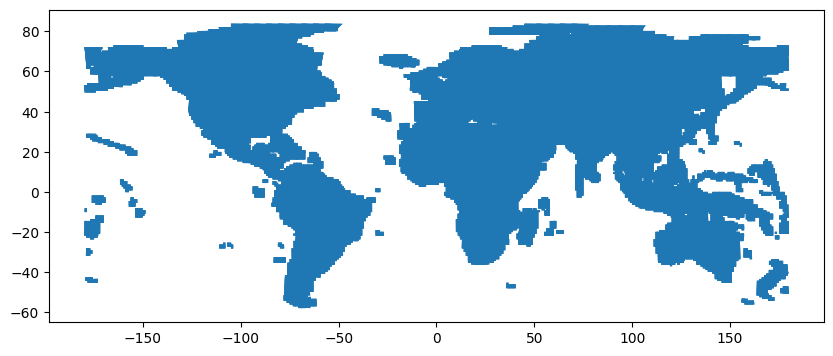

In [6]:
gdf.plot(figsize=(10,10))

In [7]:
world = gpd.read_file(
    gpd.datasets.get_path("naturalearth_lowres")
)

india = world[
    world["name"]=="India"
]

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [8]:
import pandas as pd
import geopandas as gpd
from shapely import wkb

df = pd.read_parquet(
    r"D:/farmland boundary/New folder/index.parquet"
)

df["geometry"] = df["geometry"].apply(wkb.loads)

gdf = gpd.GeoDataFrame(
    df,
    geometry="geometry",
    crs="EPSG:4326"
)

print(gdf.total_bounds)

[-179.99523907  -57.83014563  180.           83.74834535]


<Axes: >

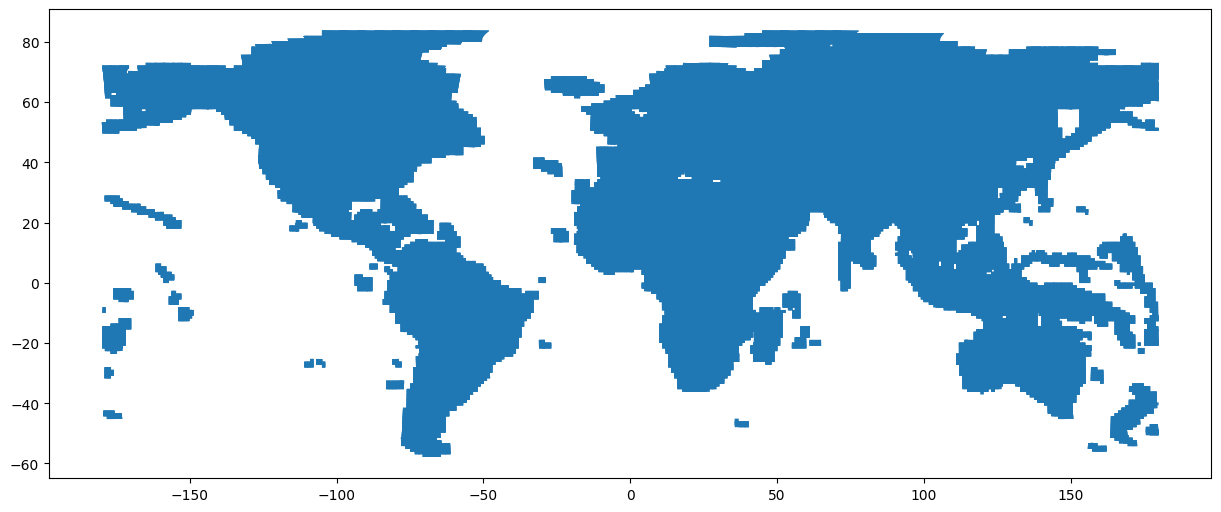

In [9]:
gdf.plot(figsize=(15,8))

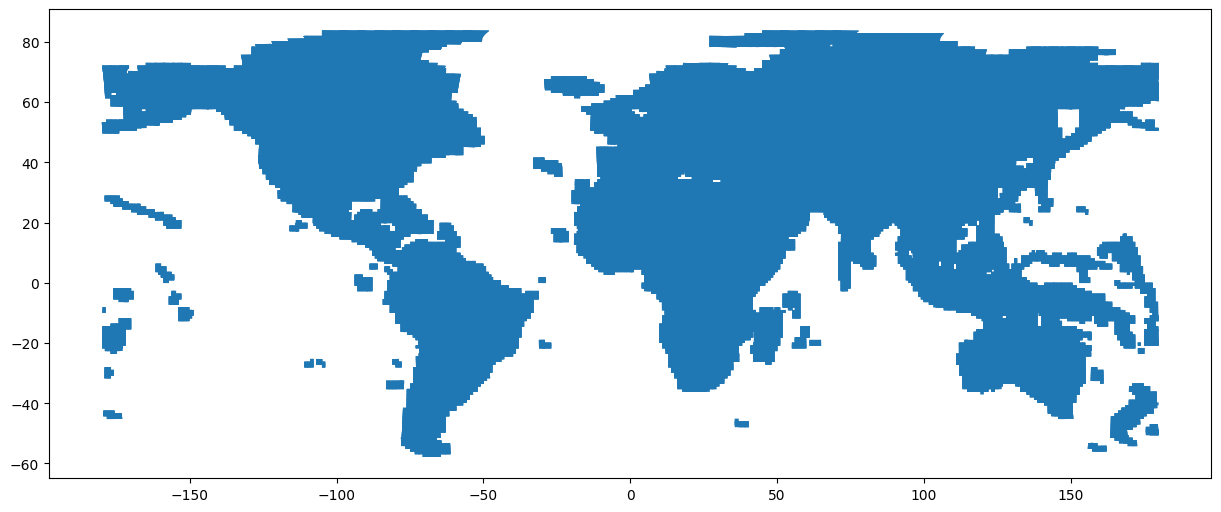

In [10]:
import matplotlib.pyplot as plt

ax = gdf.plot(figsize=(15,8))
plt.savefig("tiles.png", dpi=300)
plt.show()


In [11]:
india_tiles = gdf.cx[68:98, 6:38]

print(india_tiles.shape)
print(india_tiles[["tile_id","dataset"]].head(50))

(4240, 5)
      tile_id         dataset
28545   42NYM  s2med_planting
28546   42NYM  s2med_planting
28547   42NYN  s2med_planting
28548   42NYN  s2med_planting
28549   42NYP  s2med_planting
28550   42NYP  s2med_planting
28563   42NZM  s2med_planting
28564   42NZM  s2med_planting
28565   42NZN  s2med_planting
28566   42NZN  s2med_planting
28567   42NZP  s2med_planting
28568   42NZP  s2med_planting
28569   42PYQ  s2med_planting
28570   42PYQ  s2med_planting
28571   42PYR  s2med_planting
28572   42PYR  s2med_planting
28573   42PYS  s2med_planting
28574   42PYS  s2med_planting
28575   42PYT  s2med_planting
28576   42PYT  s2med_planting
28577   42PYU  s2med_planting
28578   42PYU  s2med_planting
28579   42PYV  s2med_planting
28580   42PYV  s2med_planting
28581   42PZA  s2med_planting
28582   42PZA  s2med_planting
28583   42PZB  s2med_planting
28584   42PZB  s2med_planting
28585   42PZC  s2med_planting
28586   42PZC  s2med_planting
28587   42PZQ  s2med_planting
28588   42PZQ  s2med_planting


In [12]:
print(india_tiles["dataset"].value_counts())

dataset
s2med_planting    2120
s2med_harvest     2120
Name: count, dtype: int64


In [13]:
print(india_tiles["tile_id"].nunique())

1060


In [14]:
india_tiles[['tile_id','dataset','url']].head(20)

,tile_id,dataset,url
28545,42NYM,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28546,42NYM,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28547,42NYN,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28548,42NYN,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28549,42NYP,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28550,42NYP,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28563,42NZM,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28564,42NZM,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28565,42NZN,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...
28566,42NZN,s2med_planting,s3://us-west-2.opendata.source.coop/tge-labs/f...


In [15]:
pd.set_option('display.max_colwidth', None)

print(
    india_tiles[['tile_id','dataset','url']]
    .head(20)
    .to_string()
)

      tile_id         dataset                                                                                                                 url
28545   42NYM  s2med_planting  s3://us-west-2.opendata.source.coop/tge-labs/ftw-global-data/features/cogs/alpha/s2med_planting/42NYM/20240101.tif
28546   42NYM  s2med_planting  s3://us-west-2.opendata.source.coop/tge-labs/ftw-global-data/features/cogs/alpha/s2med_planting/42NYM/20250101.tif
28547   42NYN  s2med_planting  s3://us-west-2.opendata.source.coop/tge-labs/ftw-global-data/features/cogs/alpha/s2med_planting/42NYN/20240101.tif
28548   42NYN  s2med_planting  s3://us-west-2.opendata.source.coop/tge-labs/ftw-global-data/features/cogs/alpha/s2med_planting/42NYN/20250101.tif
28549   42NYP  s2med_planting  s3://us-west-2.opendata.source.coop/tge-labs/ftw-global-data/features/cogs/alpha/s2med_planting/42NYP/20240101.tif
28550   42NYP  s2med_planting  s3://us-west-2.opendata.source.coop/tge-labs/ftw-global-data/features/cogs/alpha/s2med_planti

In [16]:
print(gdf["dataset"].unique())

['s2med_planting' 's2med_harvest']


In [18]:
import pandas as pd

chips = pd.read_parquet(
    r"D:\farmland boundary\New folder\chips_india.parquet"
)

print(chips.columns)
print(chips.head())

Index(['aoi_id', 'geometry', 'split'], dtype='object')
    aoi_id  \
0  g2_0000   
1  g2_0001   
2  g2_0002   
3  g2_0003   
4  g0_0004   

                                                                                                                                                                                                                                                              geometry  \
0                                             b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xb4\x01\xa4APFR@\xda0r\x91\xb1N:@6\xf7\xb5=LGR@Y]*\xe1\xbeN:@\xf1\xc9\xc6\xeaOGR@\xb0}\xb7o2K:@\x01\x94^\xf6SFR@\xf4?\x10"%K:@\xb4\x01\xa4APFR@\xda0r\x91\xb1N:@'   
1                           b"\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xb7\xc0n3w[S@\x18%'\xbf\xbd\xb99@\x8a:\n\xdbq\\S@\x19\x0e\x87\xf8\xac\xb99@\xe2\xa6w6m\\S@\xe1\x00m\xca \xb69@Q\xebG\x96r[S@\x16\xf1g\x8e1\xb69@\xb7\xc0n3w[S@\x18%'\xbf\xbd\xb99@"   
2                                   b'\x01\x03\x00\x00\x00\x01

In [19]:
import pandas as pd

chips = pd.read_parquet(
    r"D:\farmland boundary\New folder\chips_india.parquet"
)

train = chips[chips["split"]=="train"]

print(len(train))
print(train.head())

1281
     aoi_id  \
5   g2_0005   
9   g2_0009   
12  g0_0012   
14  g0_0014   
15  g2_0015   

                                                                                                                                                                                                                                                                                  geometry  \
5                                                  b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\x0c*d\x7fY\xc1R@\xf4Y Qu\x08?@\x9f\xbe\xde2a\xc2R@K\x84+\x14u\x08?@\x1b\xeeJ\x1ca\xc2R@\xcf\xedi\xc6\xe8\x04?@3;\x96rY\xc1R@\xb0CV\x03\xe9\x04?@\x0c*d\x7fY\xc1R@\xf4Y Qu\x08?@'   
9                                                           b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00_@1\xc1\x1a]T@=Z(\x92\xbd\xd7;@\xbfF\xf2S\x1a^T@\x92u\x00%\xba\xd7;@\x82a-Y\x19^T@$\xa8\xa2o-\xd4;@w4\xbd\xce\x19]T@\xcd\x94G\xdc0\xd4;@_@1\xc1\x1a]T@=Z(\x92\xbd\xd7;@'   
12                             b'\x01\x03\x00\

In [20]:
train_ids = train["aoi_id"].tolist()

print(train_ids[:20])

['g2_0005', 'g2_0009', 'g0_0012', 'g0_0014', 'g2_0015', 'g0_0019', 'g0_0021', 'g2_0023', 'g0_0025', 'g0_0026', 'g2_0028', 'g1_0031', 'g0_0032', 'g0_0033', 'g0_0034', 'g2_0035', 'g2_0037', 'g2_0038', 'g0_0039', 'g3_0040']


Downloaded window_a g2_0005
Downloaded window_b g2_0005
Downloaded semantic_3class g2_0005
Downloaded window_a g2_0009
Downloaded window_b g2_0009
Downloaded semantic_3class g2_0009
Downloaded window_a g0_0012
Downloaded window_b g0_0012
Downloaded semantic_3class g0_0012
Downloaded window_a g0_0014
Downloaded window_b g0_0014
Downloaded semantic_3class g0_0014
Downloaded window_a g2_0015
Downloaded window_b g2_0015
Downloaded semantic_3class g2_0015
Downloaded window_a g0_0019
Downloaded window_b g0_0019
Downloaded semantic_3class g0_0019
Downloaded window_a g0_0021
Downloaded window_b g0_0021
Downloaded semantic_3class g0_0021
Downloaded window_a g2_0023
Downloaded window_b g2_0023
Downloaded semantic_3class g2_0023
Downloaded window_a g0_0025
Downloaded window_b g0_0025
Downloaded semantic_3class g0_0025
Downloaded window_a g0_0026
Downloaded window_b g0_0026
Downloaded semantic_3class g0_0026
Downloaded window_a g2_0028
Downloaded window_b g2_0028
Downloaded semantic_3class g2_0028

In [24]:
import rasterio

img = rasterio.open("window_a/g0_0012.tif")

print("Shape:", img.shape)
print("Bands:", img.count)
print("Dtype:", img.dtypes)

Shape: (256, 256)
Bands: 4
Dtype: ('uint16', 'uint16', 'uint16', 'uint16')


In [25]:
import rasterio
import numpy as np

mask = rasterio.open(
    "semantic_3class/g0_0012.tif"
)

m = mask.read(1)

print("Unique Classes:",
      np.unique(m))

Unique Classes: [1 2 3]


In [26]:
import matplotlib.pyplot as plt
import rasterio

mask = rasterio.open(
    "semantic_3class/g0_0012.tif"
)

m = mask.read(1)

plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

Unique Classes: [1 2 3]


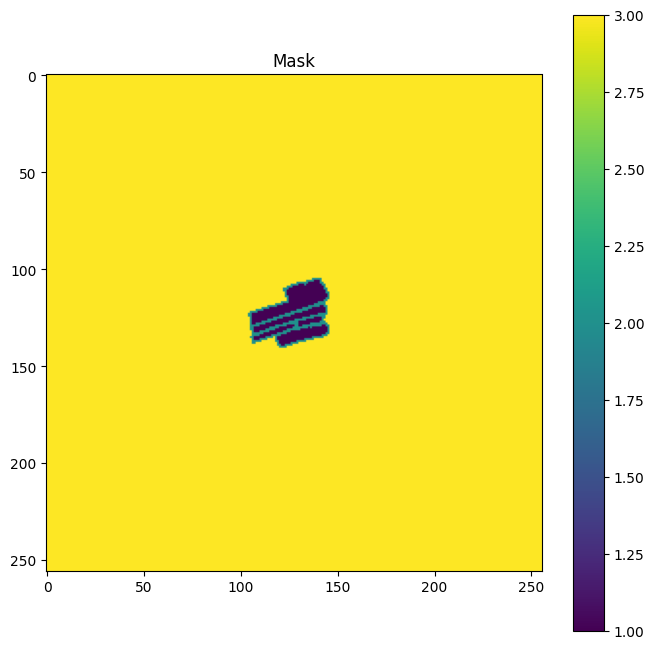

In [27]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

mask = rasterio.open(
    "semantic_3class/g0_0012.tif"
)

m = mask.read(1)

print("Unique Classes:", np.unique(m))

plt.figure(figsize=(8,8))
plt.imshow(m)
plt.colorbar()
plt.title("Mask")
plt.show()

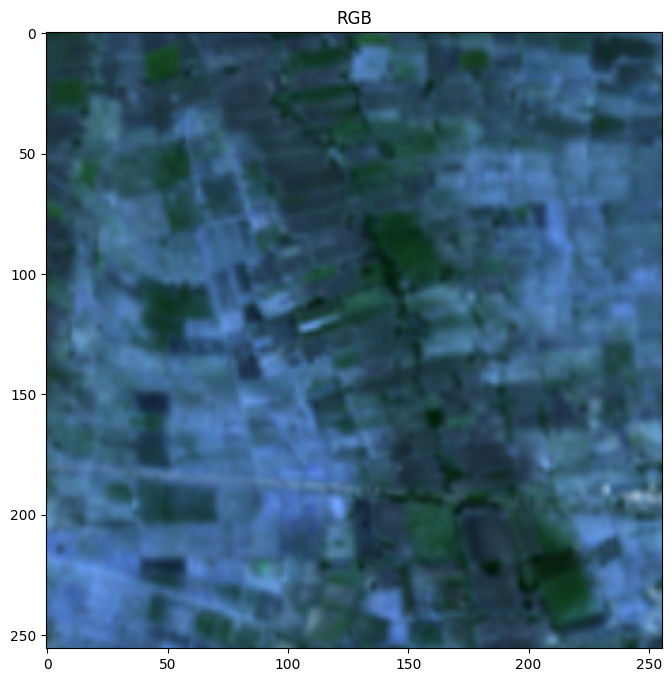

In [28]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

img = rasterio.open(
    "window_a/g0_0012.tif"
)

x = img.read()

rgb = np.stack(
    [
        x[2],
        x[1],
        x[0]
    ],
    axis=-1
)

rgb = rgb.astype(float)

rgb = (
    rgb-rgb.min()
) / (
    rgb.max()-rgb.min()
)

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.title("RGB")
plt.show()

In [29]:
import os

print("window_a =", len(os.listdir("window_a")))
print("window_b =", len(os.listdir("window_b")))
print("masks =", len(os.listdir("semantic_3class")))

window_a = 298
window_b = 293
masks = 293


In [30]:
import os

wa = set(f.replace(".tif","") for f in os.listdir("window_a"))
wb = set(f.replace(".tif","") for f in os.listdir("window_b"))
ms = set(f.replace(".tif","") for f in os.listdir("semantic_3class"))

common = wa & wb & ms

print("window_a:", len(wa))
print("window_b:", len(wb))
print("masks:", len(ms))
print("common:", len(common))

window_a: 298
window_b: 293
masks: 293
common: 291


In [31]:
import rasterio
import numpy as np

img_a = rasterio.open("window_a/g0_0012.tif").read()
img_b = rasterio.open("window_b/g0_0012.tif").read()

print("Window A:", img_a.shape)
print("Window B:", img_b.shape)

Window A: (4, 256, 256)
Window B: (4, 256, 256)


In [32]:
import numpy as np

x = np.concatenate(
    [img_a, img_b],
    axis=0
)

print(x.shape)

(8, 256, 256)


In [33]:
import rasterio
import numpy as np

mask = rasterio.open(
    "semantic_3class/g0_0012.tif"
).read(1)

unique, counts = np.unique(
    mask,
    return_counts=True
)

for u,c in zip(unique,counts):
    print(
        f"Class {u}: {c}"
    )

Class 1: 652
Class 2: 352
Class 3: 64532


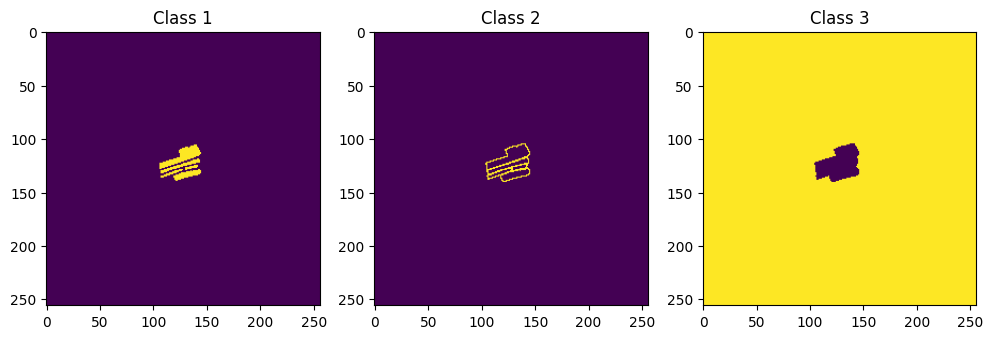

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,4))

for cls in [1,2,3]:

    plt.subplot(1,3,cls)

    plt.imshow(mask==cls)

    plt.title(
        f"Class {cls}"
    )

plt.show()

In [35]:
import os

wa = set(f.replace(".tif","") for f in os.listdir("window_a"))
wb = set(f.replace(".tif","") for f in os.listdir("window_b"))
ms = set(f.replace(".tif","") for f in os.listdir("semantic_3class"))

common = sorted(list(wa & wb & ms))

print("Samples:", len(common))

Samples: 291
